# Modeling Chronic Disease Patterns in the U.S.

In this notebook, we continue our analysis of the U.S. Chronic Disease Indicators dataset to uncover trends and patterns across different states and demographic groups.

## 🧠 Process Overview:
1. Initial data exploration and cleaning
2. Encoding and preprocessing
3. Applying clustering (unsupervised learning)
4. Validating clusters and analyzing model performance
5. Interpreting the grouped results


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("U.S._Chronic_Disease_Indicators.csv")

print(df.shape)
df.head()


(309215, 34)


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [27]:
df_small = df[["LocationDesc", "Topic", "Stratification1", "DataValue"]]

df_small = df_small.dropna(subset=["LocationDesc", "Topic", "Stratification1", "DataValue"])

df_small["DataValue"] = pd.to_numeric(df_small["DataValue"], errors="coerce")


In [28]:

pivot_df = df_small.pivot_table(
    index="LocationDesc",
    columns=["Topic", "Stratification1"],
    values="DataValue",
    aggfunc="mean"
)

pivot_df = pivot_df.apply(lambda col: col.fillna(col.mean()), axis=0)

# Check final shape
pivot_df.shape


(55, 262)

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)

kmeans = KMeans(n_clusters=4, random_state=42)
pivot_df["Cluster"] = kmeans.fit_predict(scaled_data)


pivot_df["Cluster"].value_counts()


Cluster
1    20
2    18
0    16
3     1
Name: count, dtype: int64

In [30]:

pivot_df_reset = pivot_df.reset_index()

for cluster_num in sorted(pivot_df_reset["Cluster"].unique()):
    states = pivot_df_reset[pivot_df_reset["Cluster"] == cluster_num]["LocationDesc"].tolist()
    print(f"Cluster {cluster_num} ({len(states)} states):\n{states}\n")


Cluster 0 (16 states):
['Alaska', 'Colorado', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Montana', 'New Hampshire', 'New Mexico', 'North Dakota', 'Oregon', 'South Dakota', 'Vermont', 'Washington', 'Wisconsin', 'Wyoming']

Cluster 1 (20 states):
['Arizona', 'California', 'Connecticut', 'Delaware', 'District of Columbia', 'Guam', 'Hawaii', 'Illinois', 'Kansas', 'Maryland', 'Massachusetts', 'Michigan', 'Nebraska', 'New Jersey', 'New York', 'North Carolina', 'Pennsylvania', 'Rhode Island', 'Utah', 'Virginia']

Cluster 2 (18 states):
['Alabama', 'Arkansas', 'Florida', 'Georgia', 'Indiana', 'Kentucky', 'Louisiana', 'Mississippi', 'Missouri', 'Nevada', 'Ohio', 'Oklahoma', 'Puerto Rico', 'South Carolina', 'Tennessee', 'Texas', 'Virgin Islands', 'West Virginia']

Cluster 3 (1 states):
['United States']



C:\Users\Kevin\AppData\Local\Temp\ipykernel_17048\2636201990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Cluster", data=pivot_df_reset, palette="Set2")


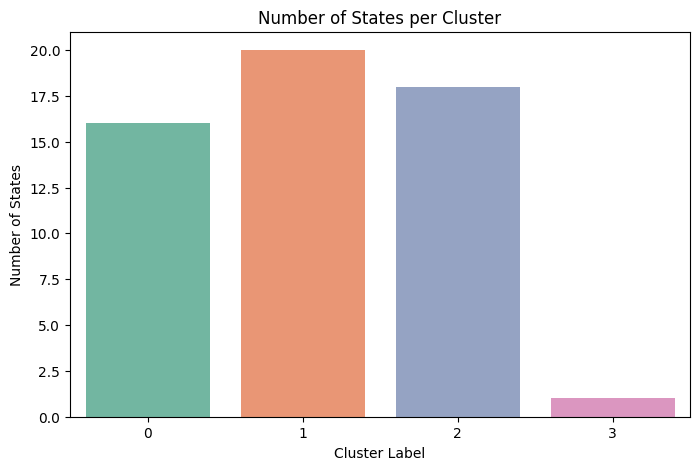

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=pivot_df_reset, palette="Set2")
plt.title("Number of States per Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Number of States")
plt.show()


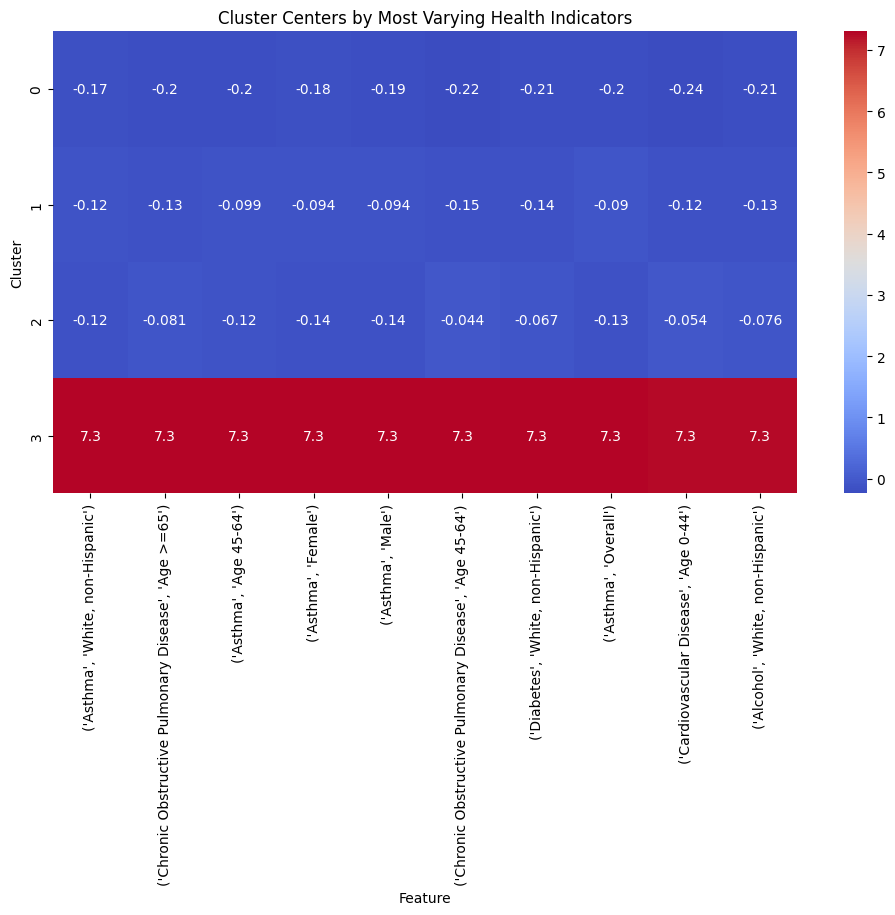

In [32]:

cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=pivot_df.columns[:-1])

top_features = cluster_centers.std().sort_values(ascending=False).head(10).index

plt.figure(figsize=(12,6))
sns.heatmap(cluster_centers[top_features], annot=True, cmap="coolwarm", xticklabels=top_features)
plt.title("Cluster Centers by Most Varying Health Indicators")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()


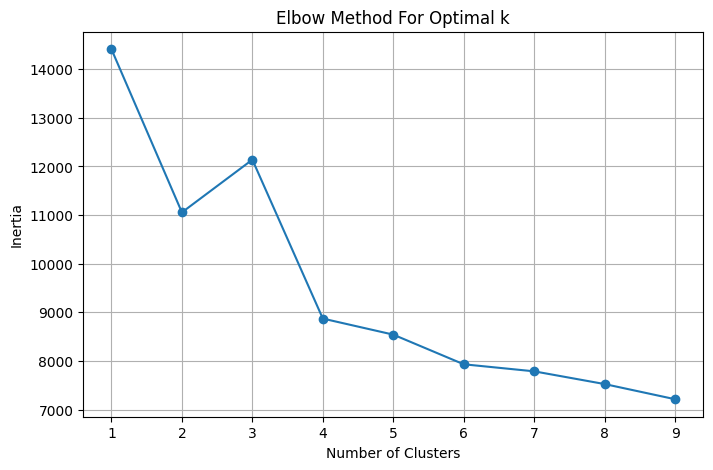

In [33]:

inertia = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


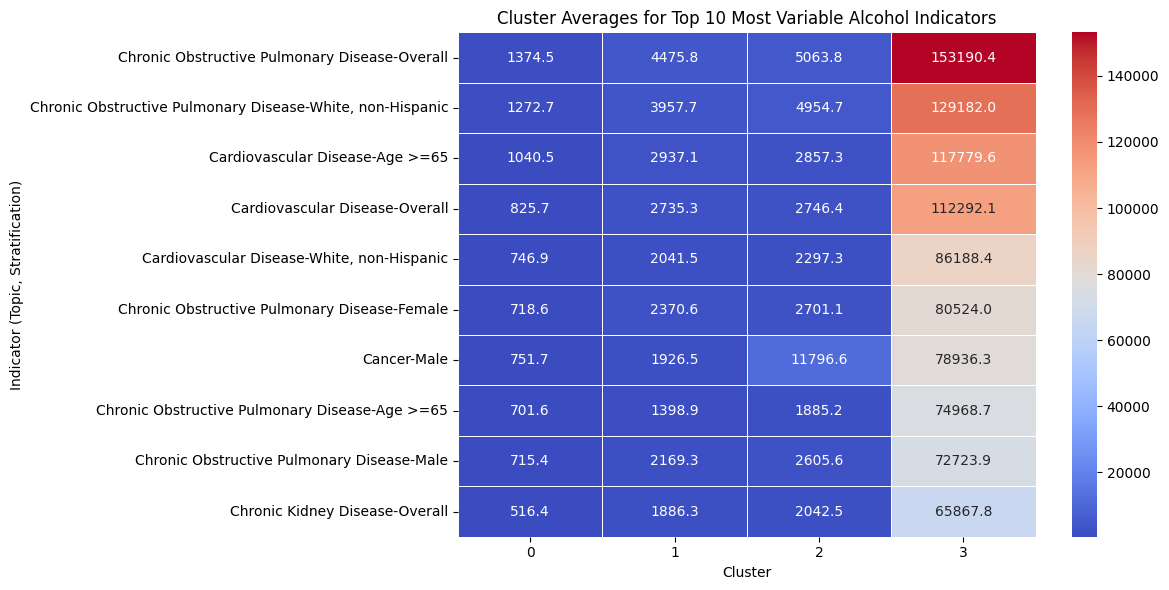

In [38]:
plt.figure(figsize=(12, 6))
sns.heatmap(top_cluster_summary, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".1f")
plt.title('Cluster Averages for Top 10 Most Variable Alcohol Indicators')
plt.xlabel('Cluster')
plt.ylabel('Indicator (Topic, Stratification)')
plt.tight_layout()
plt.show()
